**Business Understanding--> Data Collection--> Data Analysis--> Data Preprocessing--> Feature Extraction--> Data Visualization--> Model Training--> Model Evaluation--> Deployment**

***Movie recommendation system -- Data Analysis and Preprocessing***

In [90]:
#import section
import pandas as pd
from datetime import datetime, timezone

***Ratings of Movies data Processing and Feature Engineering***

In [91]:
df_ratings=pd.read_csv("E:\\Coding\\ML_projects\\Movie-Recommendation-System\\data\\raw\\mov_lens_small\\ratings.csv")
df_movies=pd.read_csv("E:\\Coding\\ML_projects\\Movie-Recommendation-System\\data\\raw\\mov_lens_small\\movies.csv")
df_links=pd.read_csv("E:\\Coding\\ML_projects\\Movie-Recommendation-System\\data\\raw\\mov_lens_small\\links.csv")
df_tags=pd.read_csv("E:\\Coding\\ML_projects\\Movie-Recommendation-System\\data\\raw\\mov_lens_small\\tags.csv")

# df_movies.head(5)

# df_links.head(5)
# df_movies.shape,df_tags.shape,df_links.shape
df_tags.drop(columns='userId',inplace=True)
df_tags.sort_values(by='movieId')

,movieId,tag,timestamp
629,1,pixar,1139045764
981,1,pixar,1137206825
2886,1,fun,1525286013
982,2,game,1137375552
33,2,fantasy,1528843929
...,...,...,...
402,187595,star wars,1528934552
529,193565,gintama,1537098603
527,193565,anime,1537098582
530,193565,remaster,1537098592


***We can do the data merging and cleaning through powerBI as well, This is a pythonic way***

In [92]:
#need to process the tags
# group by movie, then use join to combine tags into a single string while maintaining duplicates.
aggregated_tags = (df_tags.groupby(['movieId'])['tag'].apply(lambda x:', '.join(set(x))).reset_index())

#let's merge them all based on the movie id
merged_movie_links=(df_movies.merge(df_links, on=["movieId"], how='left').merge(aggregated_tags, on="movieId", how="left"))

#let's get the tags as well
merged_df=df_ratings.merge(merged_movie_links,on=["movieId"])

#as the timestap is not human readable , let's convert this into two different data(one will be utc and utc+6[for bd timezone])
utc_column=pd.to_datetime(df_ratings["timestamp"],utc=True,unit='s')
local_column=pd.to_datetime(df_ratings["timestamp"],utc=True,unit='s').dt.tz_convert('Asia/Dhaka')
merged_df.insert(loc=0, column="utc_column", value=utc_column)
merged_df.insert(loc=0, column="local_column", value=local_column)

merged_df

,local_column,utc_column,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag
0,2000-07-31 00:45:03+06:00,2000-07-30 18:45:03+00:00,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,"pixar, fun"
1,2000-07-31 00:20:47+06:00,2000-07-30 18:20:47+00:00,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,"moldy, old"
2,2000-07-31 00:37:04+06:00,2000-07-30 18:37:04+00:00,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949.0,NaN
3,2000-07-31 01:03:35+06:00,2000-07-30 19:03:35+00:00,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,"twist ending, serial killer, mystery"
4,2000-07-31 00:48:51+06:00,2000-07-30 18:48:51+00:00,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,"twist ending, thriller, mindfuck, tricky, heis..."
...,...,...,...,...,...,...,...,...,...,...,...
100831,2017-05-04 03:53:22+06:00,2017-05-03 21:53:22+00:00,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller,4972582,381288.0,NaN
100832,2017-05-04 04:21:31+06:00,2017-05-03 22:21:31+00:00,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller,4425200,324552.0,"hitman, Keanu Reeves, action, organized crime,..."
100833,2017-05-09 01:50:47+06:00,2017-05-08 19:50:47+00:00,610,168250,5.0,1494273047,Get Out (2017),Horror,5052448,419430.0,NaN
100834,2017-05-04 03:19:12+06:00,2017-05-03 21:19:12+00:00,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi,3315342,263115.0,"gritty, predictible plot, dark, heartbreaking,..."


In [93]:
#There are still some data left to preprocess like generes column data, we can make them a list.
#there are several methods to do this , i will be using the replace so that i'll not need a new column 
merged_df['genres']=merged_df['genres'].str.replace("|",",")
# merged_df.info()
# merged_df.tail()

# from the dataset info, as there are no null count less than what it should be at the tmdbid and tag, these will be our concern 
#let's check the total null value count.
print(f"Tag Column null count:{merged_df['tag'].isnull().sum()} from total row of {merged_df.shape[0]}")
print(f"tmdbId Column null count:{merged_df['tmdbId'].isnull().sum()} from total row of {merged_df.shape[0]}")

#as the tmdbid has only 13 value, we can drop those rows.
merged_df.dropna(subset=['tmdbId'], inplace=True)

#As the goal of the data to be used to give recommendation of movies.
#The system will be either content based or colleborative filtering or hybrid, where there is no need of tag.
#Another thing is that , the genres already covers the tags and the null percentage is high enough to generate noise.
#So we can remove the tag column.
merged_df.drop(columns=['tag'],inplace=True)
merged_df.info()
merged_df.to_csv("E:\\Coding/ML_projects/Movie-Recommendation-System/data/processed/processed_merged_data.csv")
merged_df

Tag Column null count:52549 from total row of 100836
tmdbId Column null count:13 from total row of 100836
<class 'pandas.core.frame.DataFrame'>
Index: 100823 entries, 0 to 100835
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype                     
---  ------        --------------   -----                     
 0   local_column  100823 non-null  datetime64[ns, Asia/Dhaka]
 1   utc_column    100823 non-null  datetime64[ns, UTC]       
 2   userId        100823 non-null  int64                     
 3   movieId       100823 non-null  int64                     
 4   rating        100823 non-null  float64                   
 5   timestamp     100823 non-null  int64                     
 6   title         100823 non-null  object                    
 7   genres        100823 non-null  object                    
 8   imdbId        100823 non-null  int64                     
 9   tmdbId        100823 non-null  float64                   
dtypes: datetime64[ns, Asia/Dhak

,local_column,utc_column,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId
0,2000-07-31 00:45:03+06:00,2000-07-30 18:45:03+00:00,1,1,4.0,964982703,Toy Story (1995),"Adventure,Animation,Children,Comedy,Fantasy",114709,862.0
1,2000-07-31 00:20:47+06:00,2000-07-30 18:20:47+00:00,1,3,4.0,964981247,Grumpier Old Men (1995),"Comedy,Romance",113228,15602.0
2,2000-07-31 00:37:04+06:00,2000-07-30 18:37:04+00:00,1,6,4.0,964982224,Heat (1995),"Action,Crime,Thriller",113277,949.0
3,2000-07-31 01:03:35+06:00,2000-07-30 19:03:35+00:00,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),"Mystery,Thriller",114369,807.0
4,2000-07-31 00:48:51+06:00,2000-07-30 18:48:51+00:00,1,50,5.0,964982931,"Usual Suspects, The (1995)","Crime,Mystery,Thriller",114814,629.0
...,...,...,...,...,...,...,...,...,...,...
100831,2017-05-04 03:53:22+06:00,2017-05-03 21:53:22+00:00,610,166534,4.0,1493848402,Split (2017),"Drama,Horror,Thriller",4972582,381288.0
100832,2017-05-04 04:21:31+06:00,2017-05-03 22:21:31+00:00,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),"Action,Crime,Thriller",4425200,324552.0
100833,2017-05-09 01:50:47+06:00,2017-05-08 19:50:47+00:00,610,168250,5.0,1494273047,Get Out (2017),Horror,5052448,419430.0
100834,2017-05-04 03:19:12+06:00,2017-05-03 21:19:12+00:00,610,168252,5.0,1493846352,Logan (2017),"Action,Sci-Fi",3315342,263115.0


***Now our data is almost ready, the next step will be some preprocessing to find more pattarn from the data to extract features***

*Feature Engineering is the systemic process of creating , transforming, or selecting variables from the data so the ml models can extract maximum predictive value*
There are several types of Feature Enginnering:
1. Feature Creation: It happens when, a new column of data can be made from the existing data(For example: the local and utc time column in the dataset we cleaned)
2. Feature Transformation: It's responsible for the data scaling methods, as by using them the data becomes more standardized and the influce of extrem outliers becomes less impectful.
3. Feature Encoding: It converts categorical data into numerical format. it's important as models can't read text directly. There are different method to do so , like, One-hot-encoding (makes all variant/selection option into a new variable/column),label encoding (it is used for the ordinal data [where order matters] to tag them as 1,2,3,...).
4. Feature Extraction/ Dimentionality reduction: Compressing large featuresets into smaller,information-rich subsets. PCA(Principal Component Analysis) is one of the processes where, suppose, you have 100 correlated numeric features and you can reduce them to a few Pricipal Componens and you will still cover 95% of the variance.
5. Feature Selection: Identifying and keeping only the most relevent features is the main moto of this. we can use correlation, ANOVA, or mutual information to find the strongest predictors. For tree based models like random forest can rank features by importance and we can keep those we want or need to get the most out of that dataset.

**Overall, 
    Feature Creation(Derive New insight),
    Transformation (Adjust Scale/Skew),
    Encoding (Handle Categorical Data),
    Extraction (Reduce Dimensions),
    Selection (Keep Best Predictors)**

In [94]:
#After doing the EDA(exploratory Data Analysis),I have found that the timestap related columns are not that much useful.so will drop them as well.
merged_df.drop(columns=['timestamp','utc_column','local_column'],inplace=True)
merged_df.head()

,userId,movieId,rating,title,genres,imdbId,tmdbId
0,1,1,4.0,Toy Story (1995),"Adventure,Animation,Children,Comedy,Fantasy",114709,862.0
1,1,3,4.0,Grumpier Old Men (1995),"Comedy,Romance",113228,15602.0
2,1,6,4.0,Heat (1995),"Action,Crime,Thriller",113277,949.0
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),"Mystery,Thriller",114369,807.0
4,1,50,5.0,"Usual Suspects, The (1995)","Crime,Mystery,Thriller",114814,629.0


In [95]:
#now, also noticed that the title column has the year of it's release. so, will extract that data to a new column named release_year.
merged_df['release_year']=merged_df['title'].str.extract(r'\((\d{4})\)', expand=False)
merged_df['release_year']=pd.to_numeric(merged_df['release_year'],errors='coerce').astype("Int64")#this corec is to avoid any error if there is any non numeric value, you can use 'ignore' as well, if you are sure that there is no non numeric value.

#as , the year is now extracted, we can remove it from the title column.
merged_df['title']=merged_df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
merged_df.head()
#Finding this kind of new data from the existing one is called feature engineering(Feature Creation).

,userId,movieId,rating,title,genres,imdbId,tmdbId,release_year
0,1,1,4.0,Toy Story,"Adventure,Animation,Children,Comedy,Fantasy",114709,862.0,1995
1,1,3,4.0,Grumpier Old Men,"Comedy,Romance",113228,15602.0,1995
2,1,6,4.0,Heat,"Action,Crime,Thriller",113277,949.0,1995
3,1,47,5.0,Seven (a.k.a. Se7en),"Mystery,Thriller",114369,807.0,1995
4,1,50,5.0,"Usual Suspects, The","Crime,Mystery,Thriller",114814,629.0,1995


In [96]:
#as we are not going to do any api work here for the tmdbId and imdbId, we can drop them as well.
merged_df.drop(columns=['tmdbId','imdbId'],inplace=True)
merged_df.head()

,userId,movieId,rating,title,genres,release_year
0,1,1,4.0,Toy Story,"Adventure,Animation,Children,Comedy,Fantasy",1995
1,1,3,4.0,Grumpier Old Men,"Comedy,Romance",1995
2,1,6,4.0,Heat,"Action,Crime,Thriller",1995
3,1,47,5.0,Seven (a.k.a. Se7en),"Mystery,Thriller",1995
4,1,50,5.0,"Usual Suspects, The","Crime,Mystery,Thriller",1995


**Some Normalization/Standardization Methods**

In [97]:
#now, we have title that is string, we can convert that to categorical data type to save some memory.
#It will also have an internal mapping of it's own and we can use that instead of movieId.
merged_df['title']=merged_df['title'].astype('category')
merged_df['title'].cat.categories#to see the unique title values.
merged_df['title'].cat.categories.size#to see how many unique title we have.

9441

In [98]:
#The relase_year columns data can affect the models overall performance, as the value is not that much distributed. 
#so, it needs to be standardized so that the value is well distributed through the dataset and will not dominate the learning of the model.
#we can use min-max scaling here.it will scale the data between 0 to 1 and will help to prevent the overflow/underflow issue during matrix operations.
from sklearn.preprocessing import MinMaxScaler

scaler_class=MinMaxScaler()
merged_df.dropna(subset=['release_year'], inplace=True)#as there are some null value, we need to drop them first before scaling.
merged_df['release_year_scaler']=scaler_class.fit_transform(merged_df[['release_year']])
#let's scale the rating column as well, to make the rating data between 0 to 1 as it normalizes the data set.
merged_df['rating_scaler']=scaler_class.fit_transform(merged_df[['rating']])
merged_df.head()

,userId,movieId,rating,title,genres,release_year,release_year_scaler,rating_scaler
0,1,1,4.0,Toy Story,"Adventure,Animation,Children,Comedy,Fantasy",1995,0.801724,0.777778
1,1,3,4.0,Grumpier Old Men,"Comedy,Romance",1995,0.801724,0.777778
2,1,6,4.0,Heat,"Action,Crime,Thriller",1995,0.801724,0.777778
3,1,47,5.0,Seven (a.k.a. Se7en),"Mystery,Thriller",1995,0.801724,1.000000
4,1,50,5.0,"Usual Suspects, The","Crime,Mystery,Thriller",1995,0.801724,1.000000


In [99]:
#genres column contains multiple value and we can make them multiple columns using one hot encoding.
genre_dummies=merged_df["genres"].str.get_dummies(sep=",")
merged_df=pd.concat([merged_df,genre_dummies],axis=1)
merged_df.head()

,userId,movieId,rating,title,genres,release_year,release_year_scaler,rating_scaler,(no genres listed),Action,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,4.0,Toy Story,"Adventure,Animation,Children,Comedy,Fantasy",1995,0.801724,0.777778,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,Grumpier Old Men,"Comedy,Romance",1995,0.801724,0.777778,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1,6,4.0,Heat,"Action,Crime,Thriller",1995,0.801724,0.777778,0,1,...,0,0,0,0,0,0,0,1,0,0
3,1,47,5.0,Seven (a.k.a. Se7en),"Mystery,Thriller",1995,0.801724,1.000000,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,50,5.0,"Usual Suspects, The","Crime,Mystery,Thriller",1995,0.801724,1.000000,0,0,...,0,0,0,0,1,0,0,1,0,0



**Before Moving to the next part, let's Discuss about the correlation, how can we understand the relation strength between different columns of the datafram and reduce columns that are not needed.**

**First of all, for measuring correlation you will need to take only the numric columns as correlation requires numeric values.**
**Correlation Helps:**
1. to identify which feature/column is more related to the target column/what we want to predict.
2. to Understand the importance and relation between columns
3. to help us decide what column should we include while traing the model.
4. to understand if there could be any important data matrix available which will be helpfull to have insight about the datafram.

**There are several correlations**
1. **Pearson Correlation:** it measures linear relationships between numeric columns, with Values range from -1 (negative correlation) to 1 (positive correlation).
2. **Spearman correlation:** it measures monotonic relationships (not necessarily linear). It’s useful if the relationship between columns isn’t linear.
3. **Point-Biserial Correlation:** it measures the relationship between a numeric column (e.g. rating) and a binary column (e.g. Adventure, Comedy). This is useful for understanding how binary features (e.g. genres) relate to ratings

In [110]:
merged_df_cleaned=merged_df.drop(columns=['genres','release_year','rating'])
numeric_columns = merged_df_cleaned.select_dtypes(include=['int64', 'float64']).columns
numeric_df = merged_df_cleaned[numeric_columns]
numeric_df.head()

,userId,movieId,release_year_scaler,rating_scaler,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,0.801724,0.777778,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,3,0.801724,0.777778,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,1,6,0.801724,0.777778,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,47,0.801724,1.000000,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,50,0.801724,1.000000,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


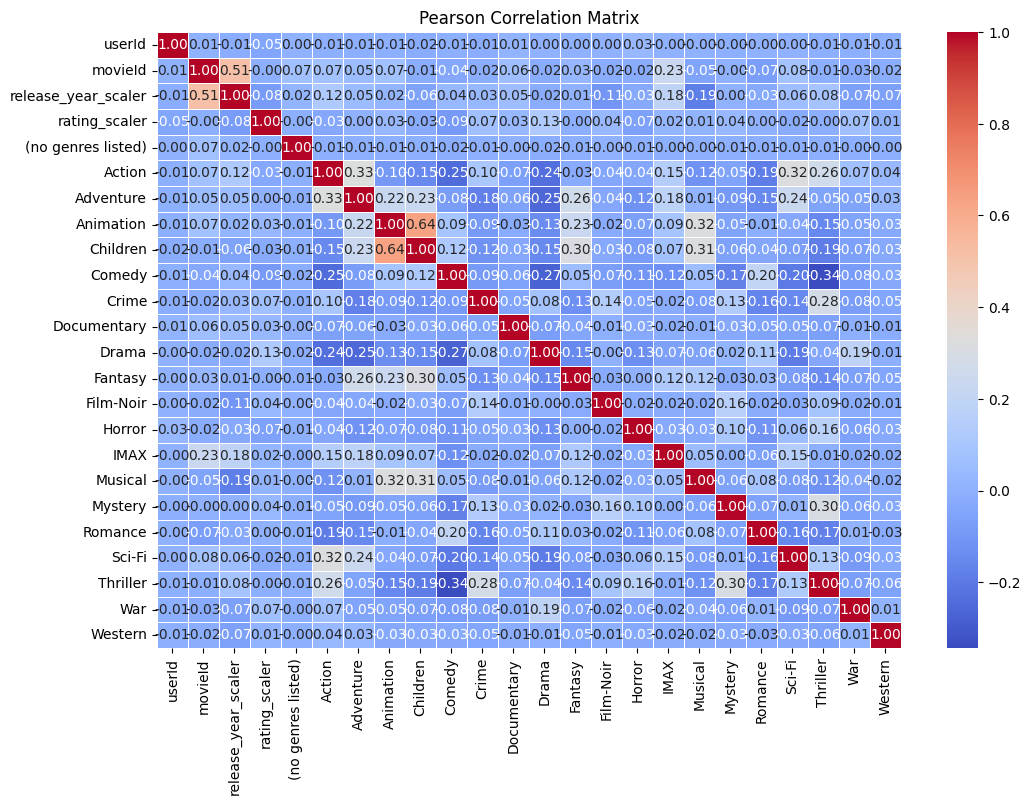

In [114]:
#pearson correlation matrix
pearson_corr = numeric_df.corr(method='pearson')

#heatmap of the Pearson correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.show()

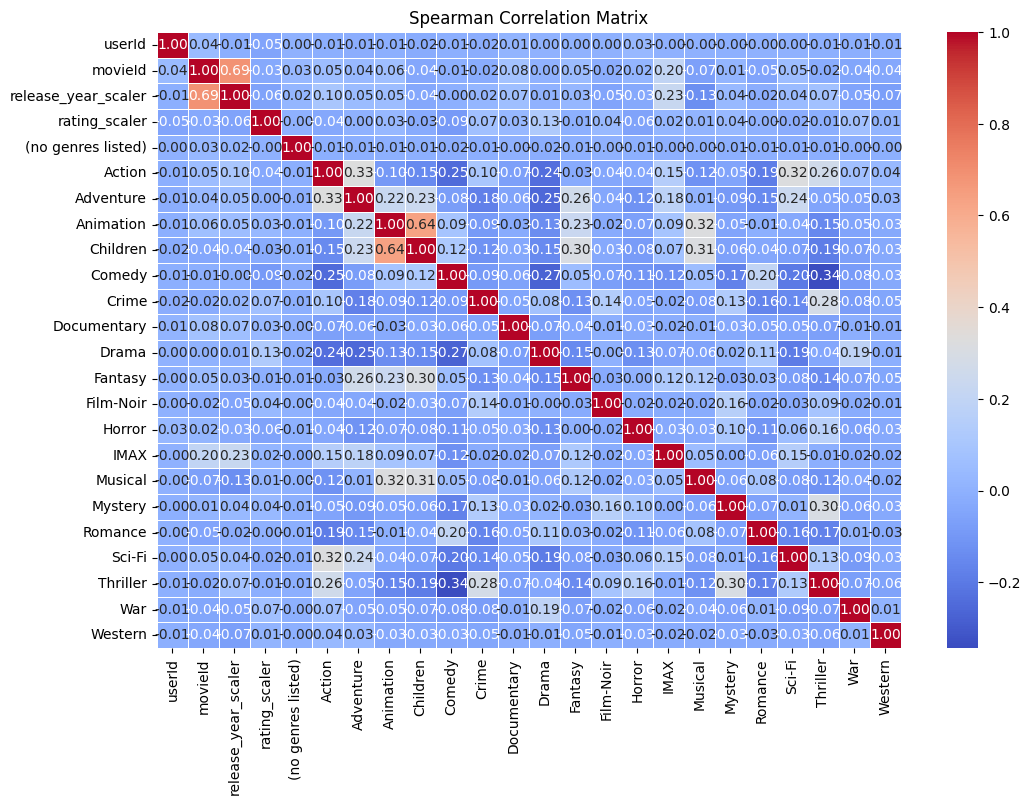

In [113]:
#Spearman Correlation Matrix
spearman_corr = numeric_df.corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Matrix")
plt.show()

**From both of the heatmap from spareman and pearson:**
**for example:**
1. Action and Adventure have a correlation of 0.33, meaning movies labeled as Action are often also labeled as Adventure. Action and Sci-fi has relation as well but less then Adventure as 0.32.
2. Animation and Children have a correlation of 0.64, meaning movies labeled as Animation are often also labeled as Children.
3. IMAX col has a relation with movieid and relase year. 
4. realese_year and movieId has a strong relation.

In [115]:
from scipy.stats import pointbiserialr

#eg:calculate point-biserial correlation between 'rating_scaler' and 'Adventure'
corr, p_value = pointbiserialr(numeric_df['rating_scaler'], numeric_df['Adventure'])

print(f"Point-Biserial correlation between 'rating_scaler' and 'Adventure': {corr:.2f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial correlation between 'rating_scaler' and 'Adventure': 0.00
P-value: 0.2271


**Now the data is ready for the next move, which will be relation finding part. For example, we can have a user_movie interaction matrix or movie popularity matrix which will help use later,as our model will have favourite movie name and then suggest simmilar movie. All the data we have in the dataset are now cleaned and normalized.**

In [100]:
user_movie_matrix=merged_df.pivot_table(index='userId',columns='title',values='rating')
user_movie_matrix.head()
#this will be very useful for collaborative filtering based recommendation system.
#pivot table is a great way to create such matrix from the cleaned data.index will be the userId, columns will be the movie title and values will be the rating.
#this will be a sparse matrix as not every user will rate every movie.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7468\1574404152.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  user_movie_matrix=merged_df.pivot_table(index='userId',columns='title',values='rating')


title,'71,'Hellboy': The Seeds of Creation,'Round Midnight,'Salem's Lot,'Til There Was You,'Tis the Season for Love,"'burbs, The",'night Mother,(500) Days of Summer,*batteries not included,...,Zulu,[REC],[REC]²,[REC]³ 3 Génesis,anohana: The Flower We Saw That Day - The Movie,eXistenZ,xXx,xXx: State of the Union,¡Three Amigos!,À nous la liberté (Freedom for Us)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
from sklearn.metrics.pairwise import cosine_similarity

#only content-related columns (like genres and release_year_scaler) are used to find similarity. other columns should be excluded.
#make sure there is no null value in the dataframe.
# content_features = merged_df.drop(columns=['userId', 'movieId', 'rating', 'title', 'genres','release_year'])
# content_similarity = cosine_similarity(content_features)#it will calculat the CS between all the moveies based on the features.
# content_similarity_df = pd.DataFrame(content_similarity, index=merged_df['title'], columns=merged_df['title'])#making the similarity matrix a dataframe for better visualization and handling.
# content_similarity_df.head()

# [Tried This but device and ran out of memory as the matrix will be very large, you can use ANN or other methods to find similar movies based on content features.]
# --- IGNORE --- this part is ignored.

In [116]:
# Now let's save the cleaned and preprocessed data to a new csv file for future use.
merged_df.to_csv("E:\\Coding/ML_projects/Movie-Recommendation-System/data/processed/cleaned_data_final.csv", index=False)